# HW 5, Problem 5: 4DVAR

## The cycle

4DVAR uses the same observations, truth, and initial guess as Problem 3 (both are built by `da_models.hw5`). At each observation time $t_k$, with background $\mu_k$ (the forecast that arrived at $t_k$; $\mu_0$ is the climatological mean), minimize

$$\mathcal L(x) = \tfrac12 \|R^{-1/2}(y_{k+1} - H M(x))\|_2^2 + \tfrac12 \|B^{-1/2}(x - \mu_k)\|_2^2$$

over the state $x$ at $t_k$, set $\tilde x_k$ to the minimizer, and forecast from it over $[t_k, t_{k+1}]$. The forecast that arrives at $t_{k+1}$ is the next background. Unlike 3DVAR, the correction is chosen so that the model trajectory itself fits the next observation.

## The gradient

The background term's gradient is direct. For the observation term, one forward solve over $[t_k, t_{k+1}]$ gives $M(x)$ and the misfit; then the continuous adjoint $\lambda' = -(Df)^T\lambda$ is integrated backward from $\lambda(t_{k+1}) = H^T R^{-1}(HM(x) - y_{k+1})$, and $\lambda(t_k)$ is the gradient (Problem 4). The adjoint uses the **analytic Jacobians** in `jacobians.py`, through the `jac_func` hook in `adjoint.py`. The 4DVAR code is in `var4d.py`; the forecast/analysis cycle and 3DVAR are reused from Problem 3 (`assimilation.py`).

## Solving it

- **Control-variable transform.** Write $x = \mu_k + L_B w$ with $B = L_B L_B^T$. The background term becomes $\tfrac12\|w\|^2$ and $\nabla_w \mathcal L = w + L_B^T \nabla_x J_o$. Same minimizer, but $B^{-1}$ is never formed (the Sturis $B$ has condition number $\sim 10^{11}$) and the problem is better conditioned for the optimizer.
- **Optimizer.** L-BFGS-B starting from $w = 0$ (the background), stopping when the relative decrease in $\mathcal L$ per iteration drops below $10^{-8}$. Each cost/gradient evaluation is one forward plus one adjoint solve over a single window.

In [1]:
import pickle
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from da_models import hw5
from da_models.adjoint import numerical_jacobian
from da_models.assimilation import make_3dvar, free_run, run_cycle, final_time_rmse
from da_models.da_plots import plot_case_timeseries, plot_case_hovmoller
from da_models.jacobians import JACOBIANS, lorenz63_jacobian
from da_models.var4d import make_4dvar, make_observation_term, time_integrated_rmse
from da_models.compare_plots import plot_method_comparison

DATA_DIR = Path("../data")   # adjust if running in Colab
CACHE_DIR = DATA_DIR / "cache_4dvar"
CACHE_DIR.mkdir(exist_ok=True)
RECOMPUTE = False            # True: rerun 4DVAR even if cached results exist

models = {name: hw5.load_model(name, DATA_DIR) for name in hw5.MODELS}

## Checks

**1. Analytic Jacobians** against central finite differences, at 10 states along each true trajectory.

In [2]:
for name, model in models.items():
    case = hw5.build_case(model, "identity", 0.01)
    worst = 0.0
    for x in case["truth"][::10, 0]:
        Ja = JACOBIANS[name](x, **model["params"])
        Jn = numerical_jacobian(model["rhs"], 0.0, x, model["params"])
        worst = max(worst, np.abs(Ja - Jn).max() / np.abs(Ja).max())
    print(f"{name:9s} max relative difference: {worst:.1e}")

lorenz63  max relative difference: 2.1e-10


lorenz96  max relative difference: 4.4e-10
sturis    max relative difference: 1.5e-10


**2. Adjoint gradient of the observation term** against a centered finite difference along a random direction (scaled by $\sqrt{B_{ii}}$ so the step is meaningful for every variable), for every model and operator at 10% noise.

In [3]:
rng = np.random.default_rng(1)
for name, model in models.items():
    sd = np.sqrt(np.diag(model["B"]))
    for op in hw5.MODELS[name]["operators"]:
        case = hw5.build_case(model, op, 0.10)
        obs_term = make_observation_term(model["rhs"], model["params"], JACOBIANS[name],
                                         case["dt"], case["H"], case["R"])
        x = case["truth"][3, 0] + 0.5 * sd * rng.standard_normal(len(sd))
        y = case["Y"][3]
        d = rng.standard_normal(len(sd)); d *= sd / np.linalg.norm(d)
        _, grad = obs_term(x, y)
        eps = 1e-5
        fd = (obs_term(x + eps * d, y)[0] - obs_term(x - eps * d, y)[0]) / (2 * eps)
        print(f"{name:9s} {op:17s} adjoint {grad @ d: .10e}   FD {fd: .10e}   rel. diff {abs(grad @ d - fd) / abs(fd):.1e}")

lorenz63  identity          adjoint  1.5682544822e+01   FD  1.5682544802e+01   rel. diff 1.2e-09


lorenz63  x only            adjoint  5.9024283283e-01   FD  5.9024283293e-01   rel. diff 1.8e-10


lorenz96  identity          adjoint  1.6399168996e+02   FD  1.6399168998e+02   rel. diff 7.8e-11


lorenz96  every other site  adjoint -8.4894249596e+01   FD -8.4894249551e+01   rel. diff 5.3e-10
sturis    identity          adjoint -2.9701212348e+00   FD -2.9701212368e+00   rel. diff 6.6e-10
sturis    glucose only      adjoint -5.1484050131e+00   FD -5.1484050146e+00   rel. diff 2.9e-10


**3. The control-variable transform finds the same minimizer** as minimizing $\mathcal L(x)$ directly with $B^{-1}$ (Lorenz-63, where $B$ is well conditioned).

In [4]:
model = models["lorenz63"]
case = hw5.build_case(model, "x only", 0.10)
obs_term = make_observation_term(model["rhs"], model["params"], lorenz63_jacobian,
                                 case["dt"], case["H"], case["R"])
background = case["truth"][2, -1] + np.array([2.0, -1.0, 3.0])
B_inv = np.linalg.inv(model["B"])

def L_x(x):
    Jo, g = obs_term(x, case["Y"][3])
    return Jo + 0.5 * (x - background) @ B_inv @ (x - background), g + B_inv @ (x - background)

x_direct = minimize(L_x, background, jac=True, method="L-BFGS-B", options=dict(gtol=1e-8)).x
x_transform = make_4dvar(obs_term, model["B"], case["Y"])(3, background)
print("direct (B^-1):        ", x_direct)
print("control variable w:   ", x_transform)
print("max difference:       ", np.abs(x_direct - x_transform).max())

direct (B^-1):         [14.71873658 17.66249798 24.04687163]
control variable w:    [14.71830201 17.66290782 24.04701013]
max difference:        0.0004345666470282339


**4. Cost of one gradient:** analytic Jacobian vs. the finite-difference Jacobian `adjoint.py` uses by default (one forward + one adjoint solve over a single window).

In [5]:
for name, model in models.items():
    case = hw5.build_case(model, "identity", 0.10)
    x, y = case["truth"][3, 0], case["Y"][3]
    times = {}
    for label, jac in [("analytic", JACOBIANS[name]), ("finite diff.", None)]:
        obs_term = make_observation_term(model["rhs"], model["params"], jac,
                                         case["dt"], case["H"], case["R"])
        tic = time.perf_counter()
        for _ in range(5):
            obs_term(x, y)
        times[label] = (time.perf_counter() - tic) / 5
    print(f"{name:9s} analytic {1e3 * times['analytic']:7.1f} ms   finite diff. {1e3 * times['finite diff.']:7.1f} ms"
          f"   speed-up {times['finite diff.'] / times['analytic']:.1f}x")

lorenz63  analytic     6.4 ms   finite diff.    11.0 ms   speed-up 1.7x


lorenz96  analytic    13.6 ms   finite diff.   320.3 ms   speed-up 23.5x
sturis    analytic     1.1 ms   finite diff.     3.2 ms   speed-up 2.8x


## Run every case

3DVAR is rerun here (it takes a fraction of a second per case) so both methods are timed on the same machine. 4DVAR takes several minutes in total, mostly for Lorenz-96 with every other site observed, so each case is cached in `data/cache_4dvar/` (set `RECOMPUTE = True` to redo it). Timing is the wall-clock time of the full cycle on $[0, 10]$.

In [6]:
def cache_path(case):
    op = case["operator"].replace(" ", "_")
    return CACHE_DIR / f"{case['model']}__{op}__{case['noise_level']:.2f}.pkl"

results_3d = {name: [] for name in models}
results_4d = {name: [] for name in models}
opt_stats = {}
free_runs = {}

for name, model in models.items():
    for op in hw5.MODELS[name]["operators"]:
        for p in hw5.NOISE_LEVELS:
            case = hw5.build_case(model, op, p)

            run3 = run_cycle(case["propagate"], case["x_guess0"], case["n_cycles"],
                             make_3dvar(case["H"], case["R"], model["B"], case["Y"]))
            results_3d[name].append((case, run3))

            path = cache_path(case)
            if path.exists() and not RECOMPUTE:
                with open(path, "rb") as f:
                    run4, stats = pickle.load(f)
            else:
                obs_term = make_observation_term(model["rhs"], model["params"], JACOBIANS[name],
                                                 case["dt"], case["H"], case["R"])
                analyze = make_4dvar(obs_term, model["B"], case["Y"])
                run4 = run_cycle(case["propagate"], case["x_guess0"], case["n_cycles"], analyze)
                stats = list(analyze.stats)
                with open(path, "wb") as f:
                    pickle.dump((run4, stats), f)
            results_4d[name].append((case, run4))
            opt_stats[(name, op, p)] = stats
            print(f"{name:9s} {op:17s} {p:4.0%}  3DVAR {run3['wall_time']:6.2f} s   4DVAR {run4['wall_time']:7.1f} s")

    case0 = results_3d[name][0][0]
    free_runs[name] = run_cycle(case0["propagate"], case0["x_guess0"], case0["n_cycles"], free_run())

lorenz63  identity            1%  3DVAR   0.11 s   4DVAR     9.2 s


lorenz63  identity           10%  3DVAR   0.13 s   4DVAR     8.6 s


lorenz63  x only              1%  3DVAR   0.12 s   4DVAR     3.7 s


lorenz63  x only             10%  3DVAR   0.12 s   4DVAR     5.6 s


lorenz96  identity            1%  3DVAR   0.38 s   4DVAR    60.7 s


lorenz96  identity           10%  3DVAR   0.36 s   4DVAR    60.1 s


lorenz96  every other site    1%  3DVAR   0.40 s   4DVAR    74.7 s


lorenz96  every other site   10%  3DVAR   0.46 s   4DVAR    70.5 s


sturis    identity            1%  3DVAR   0.03 s   4DVAR     1.7 s
sturis    identity           10%  3DVAR   0.03 s   4DVAR     0.8 s
sturis    glucose only        1%  3DVAR   0.03 s   4DVAR     0.5 s
sturis    glucose only       10%  3DVAR   0.03 s   4DVAR     0.5 s


## Accuracy and cost

- **RMSE $[0,T]$:** the assignment's time-integrated RMSE.
- **RMSE $[1,T]$:** the same integral after the first time unit. The two methods treat the first window differently: 3DVAR's first window is an uncorrected forecast from the initial guess (it has no $y_0$), while 4DVAR's first window is already fit to $y_1$. Leaving out the spin-up compares how well each method tracks once it is running.
- **Scaled:** the $[0,T]$ RMSE after dividing each variable by $\sqrt{B_{ii}}$, divided by $\sqrt n$ (1 = error as large as the natural variability). This matters for Sturis.
- **Evals/cycle:** forward+adjoint solves per 4DVAR window (L-BFGS function evaluations), averaged over the 100 cycles.

In [7]:
def scaled_rmse(case, run, model):
    sd = np.sqrt(np.diag(model["B"]))
    return time_integrated_rmse(case["truth"] / sd, run["segments"] / sd, case["dt"]) / np.sqrt(len(sd))

skip = int(round(1.0 / hw5.DT_OBS))
header = (f"{'model':<9} {'observing':<17} {'noise':>5} {'method':>6} {'RMSE [0,T]':>10} {'RMSE [1,T]':>10} "
          f"{'RMSE at T':>9} {'scaled':>6} {'time (s)':>8} {'evals/cyc':>9}")
print(header); print("-" * len(header))
for name, model in models.items():
    for (case, r3), (_, r4) in zip(results_3d[name], results_4d[name]):
        stats = opt_stats[(name, case["operator"], case["noise_level"])]
        for method, run, evals in [("3DVAR", r3, "-"), ("4DVAR", r4, f"{np.mean([s['nfev'] for s in stats]):.1f}")]:
            print(f"{name:<9} {case['operator']:<17} {case['noise_level']:>5.0%} {method:>6} "
                  f"{time_integrated_rmse(case['truth'], run['segments'], case['dt']):>10.4g} "
                  f"{time_integrated_rmse(case['truth'], run['segments'], case['dt'], skip):>10.4g} "
                  f"{final_time_rmse(case['truth'], run):>9.4g} {scaled_rmse(case, run, model):>6.3f} "
                  f"{run['wall_time']:>8.2f} {evals:>9}")
    print()

n_unconverged = sum(not s["success"] for stats in opt_stats.values() for s in stats)
print(f"4DVAR windows where L-BFGS hit its iteration limit: {n_unconverged} of {100 * len(opt_stats)}")

model     observing         noise method RMSE [0,T] RMSE [1,T] RMSE at T scaled time (s) evals/cyc
--------------------------------------------------------------------------------------------------
lorenz63  identity             1%  3DVAR     0.5501     0.1348    0.1303  0.037     0.11         -
lorenz63  identity             1%  4DVAR     0.2555     0.2615    0.1284  0.018     9.24      16.6
lorenz63  identity            10%  3DVAR      1.402      1.325      1.24  0.094     0.13         -
lorenz63  identity            10%  4DVAR      1.503      1.534    0.8677  0.103     8.63      15.3
lorenz63  x only               1%  3DVAR     0.6874     0.1885    0.1815  0.046     0.12         -
lorenz63  x only               1%  4DVAR     0.4965     0.1634    0.1571  0.033     3.74       6.4
lorenz63  x only              10%  3DVAR      2.047      1.859     1.806  0.137     0.12         -
lorenz63  x only              10%  4DVAR      1.621      1.611     1.588  0.109     5.57      10.3

lorenz96 

## 3DVAR vs. 4DVAR at a glance

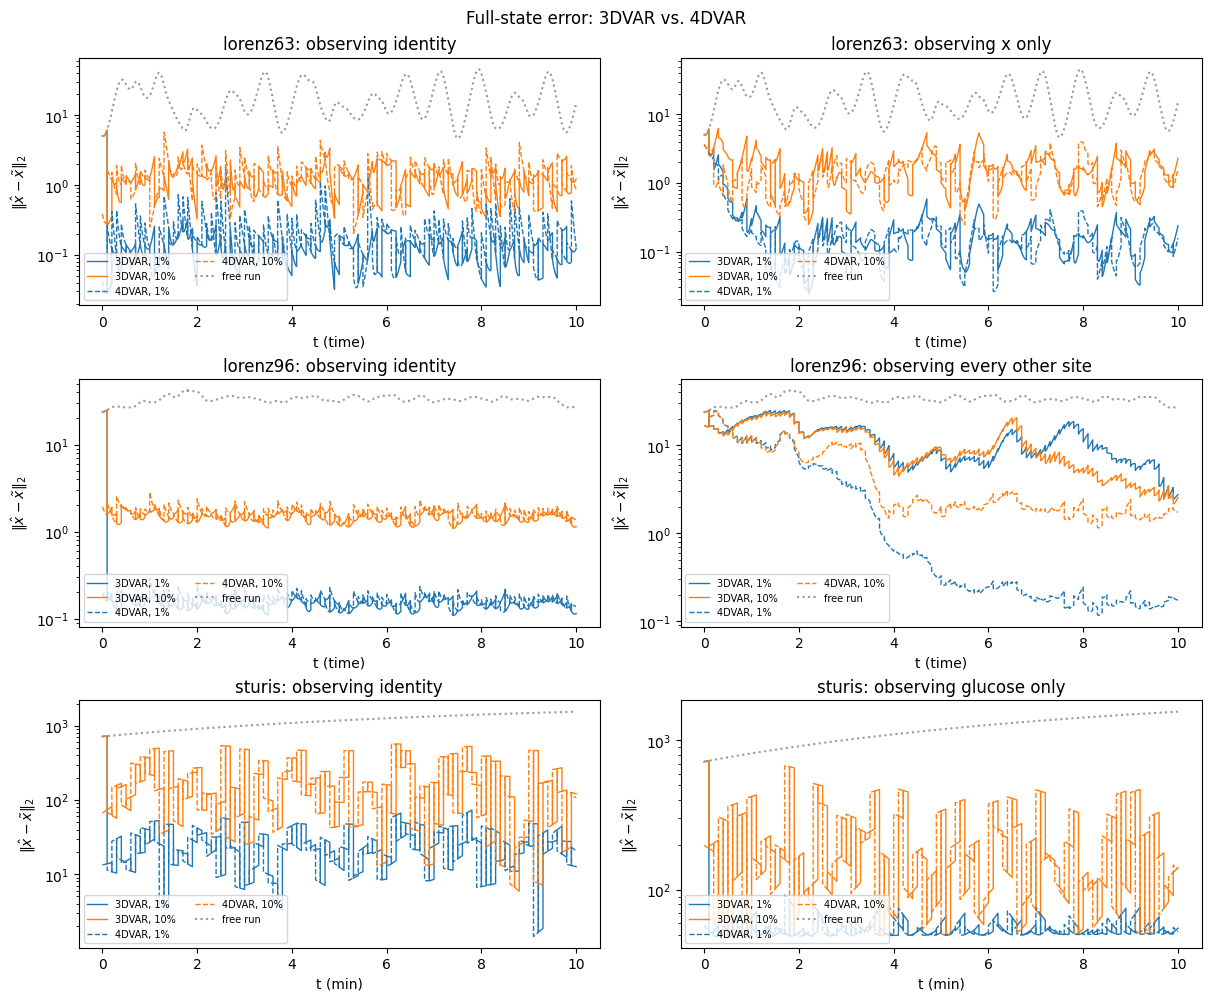

In [8]:
plot_method_comparison(models, {"3DVAR": results_3d, "4DVAR": results_4d}, free_runs)
plt.show()

**Discussion:** 

## 4DVAR results by model

### Lorenz-63

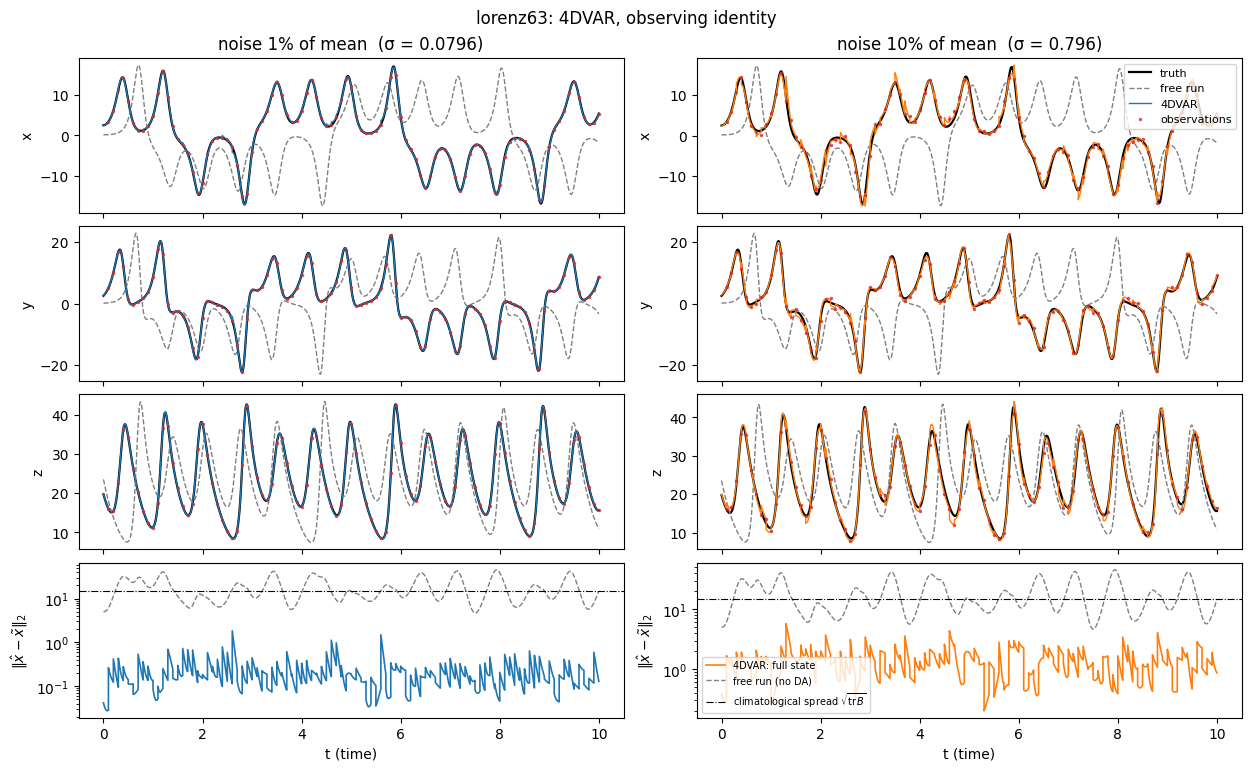

In [9]:
name = "lorenz63"
cr = [(c, r) for c, r in results_4d[name] if c["operator"] == "identity"]
plot_case_timeseries(models[name], [c for c, _ in cr], [r for _, r in cr], free_runs[name], method="4DVAR")
plt.show()

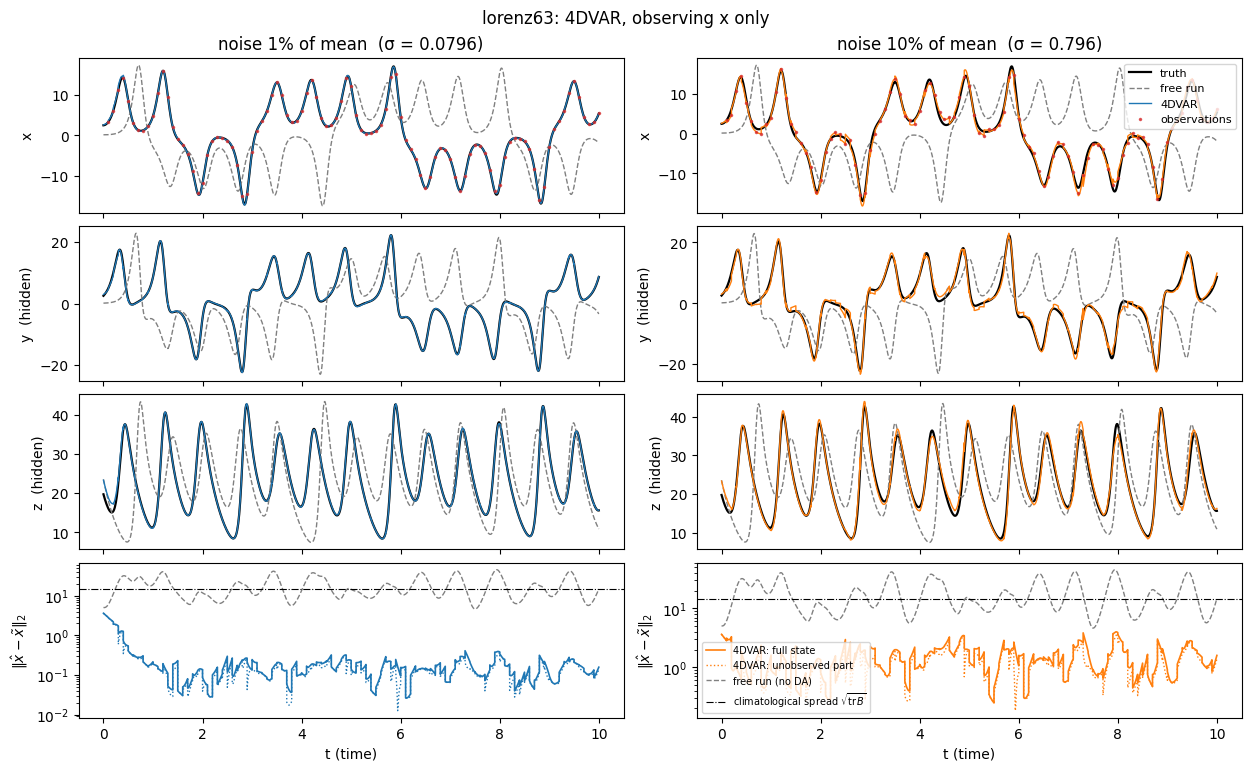

In [10]:
name = "lorenz63"
cr = [(c, r) for c, r in results_4d[name] if c["operator"] == "x only"]
plot_case_timeseries(models[name], [c for c, _ in cr], [r for _, r in cr], free_runs[name], method="4DVAR")
plt.show()

### Lorenz-96

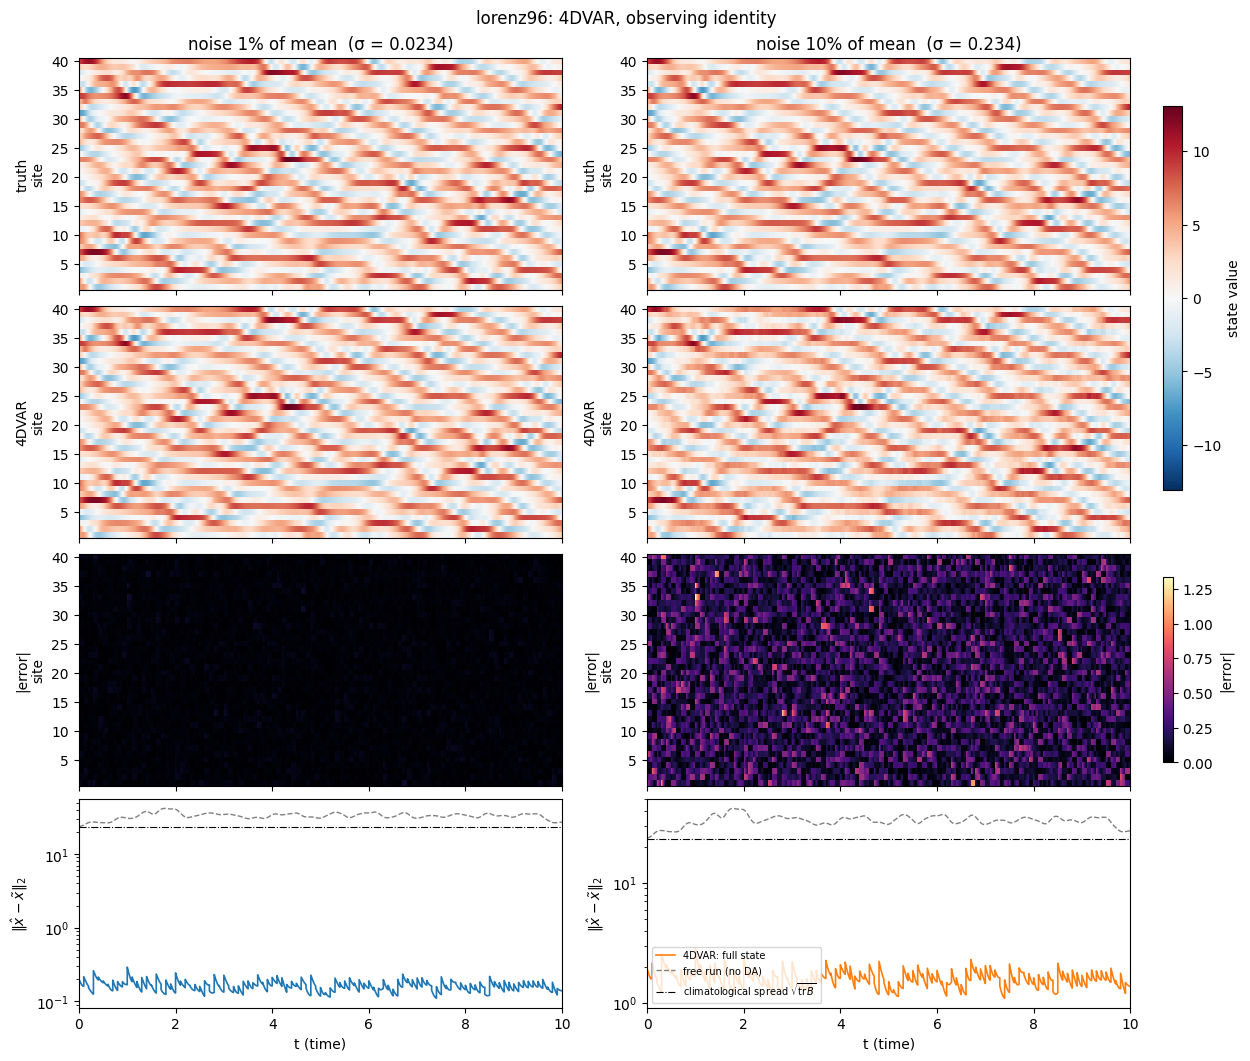

In [11]:
name = "lorenz96"
cr = [(c, r) for c, r in results_4d[name] if c["operator"] == "identity"]
plot_case_hovmoller(models[name], [c for c, _ in cr], [r for _, r in cr], free_runs[name], method="4DVAR")
plt.show()

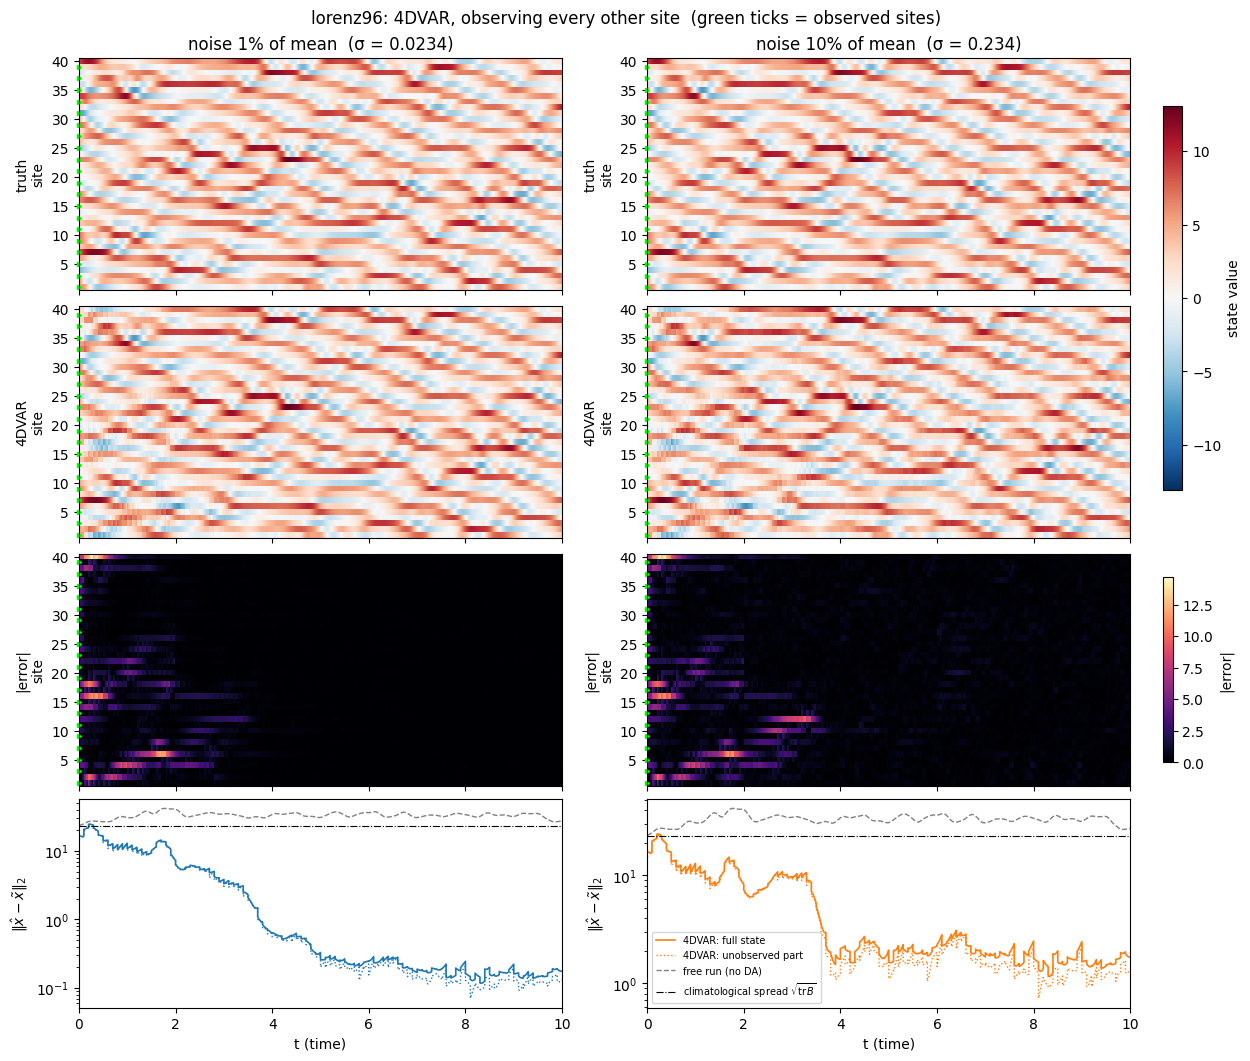

In [12]:
name = "lorenz96"
cr = [(c, r) for c, r in results_4d[name] if c["operator"] == "every other site"]
plot_case_hovmoller(models[name], [c for c, _ in cr], [r for _, r in cr], free_runs[name], method="4DVAR")
plt.show()

### Sturis ($I_G = 216$ mg/min)

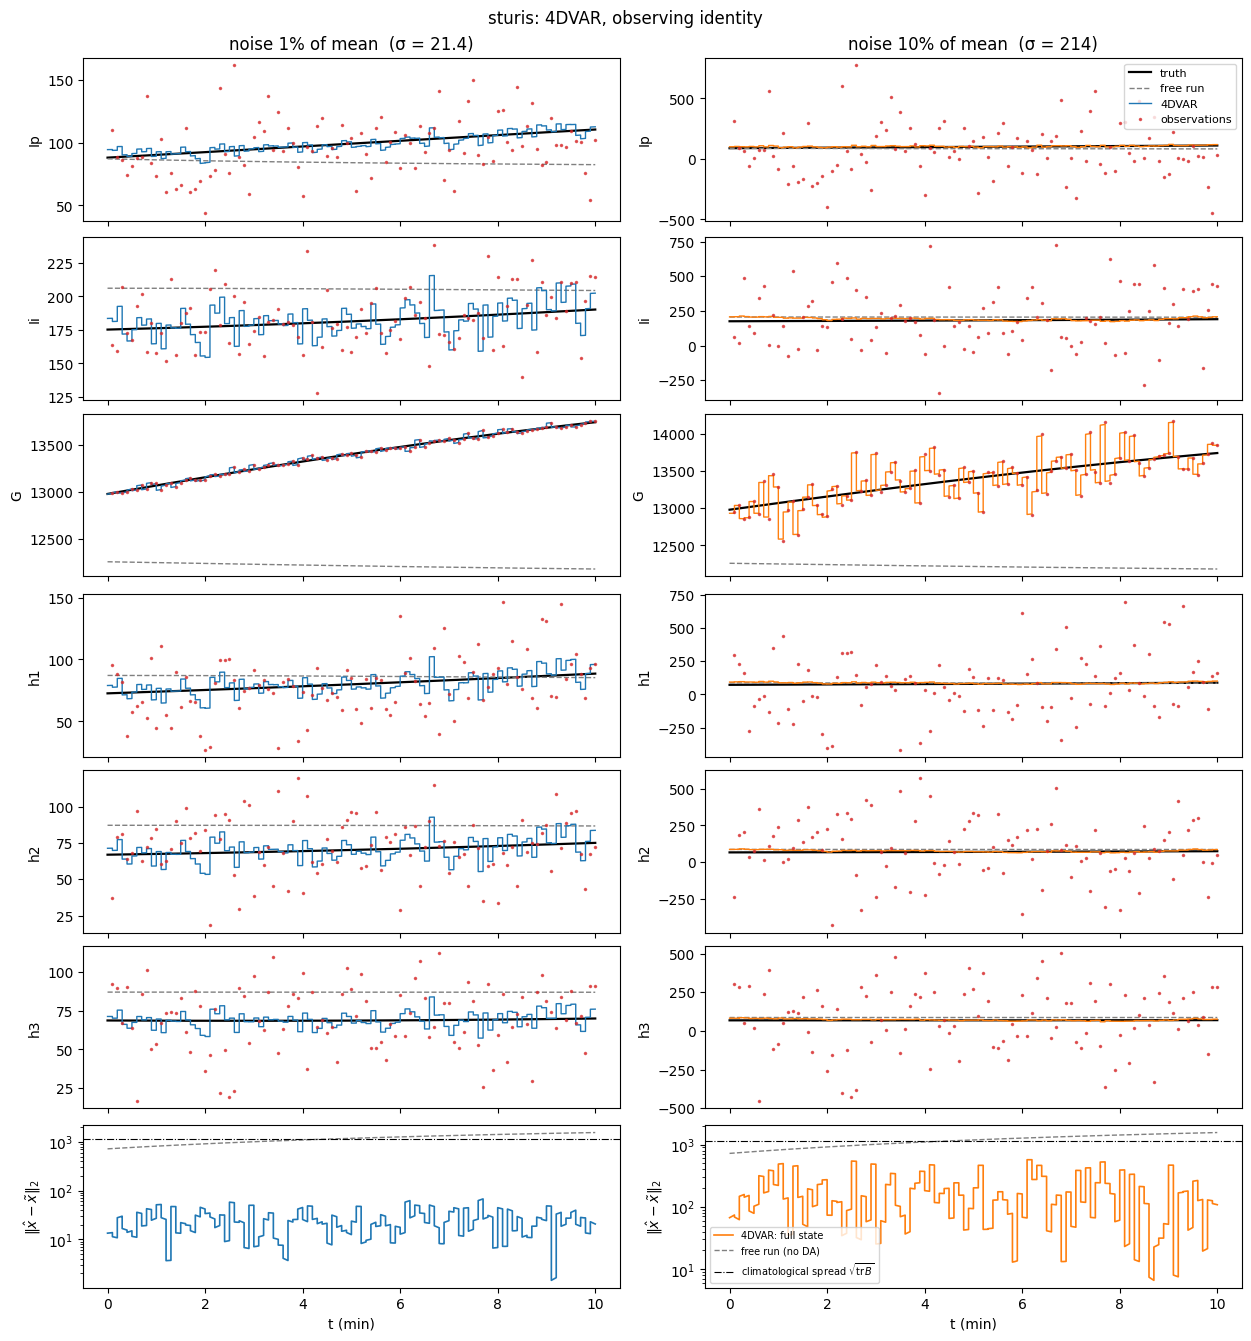

In [13]:
name = "sturis"
cr = [(c, r) for c, r in results_4d[name] if c["operator"] == "identity"]
plot_case_timeseries(models[name], [c for c, _ in cr], [r for _, r in cr], free_runs[name], method="4DVAR")
plt.show()

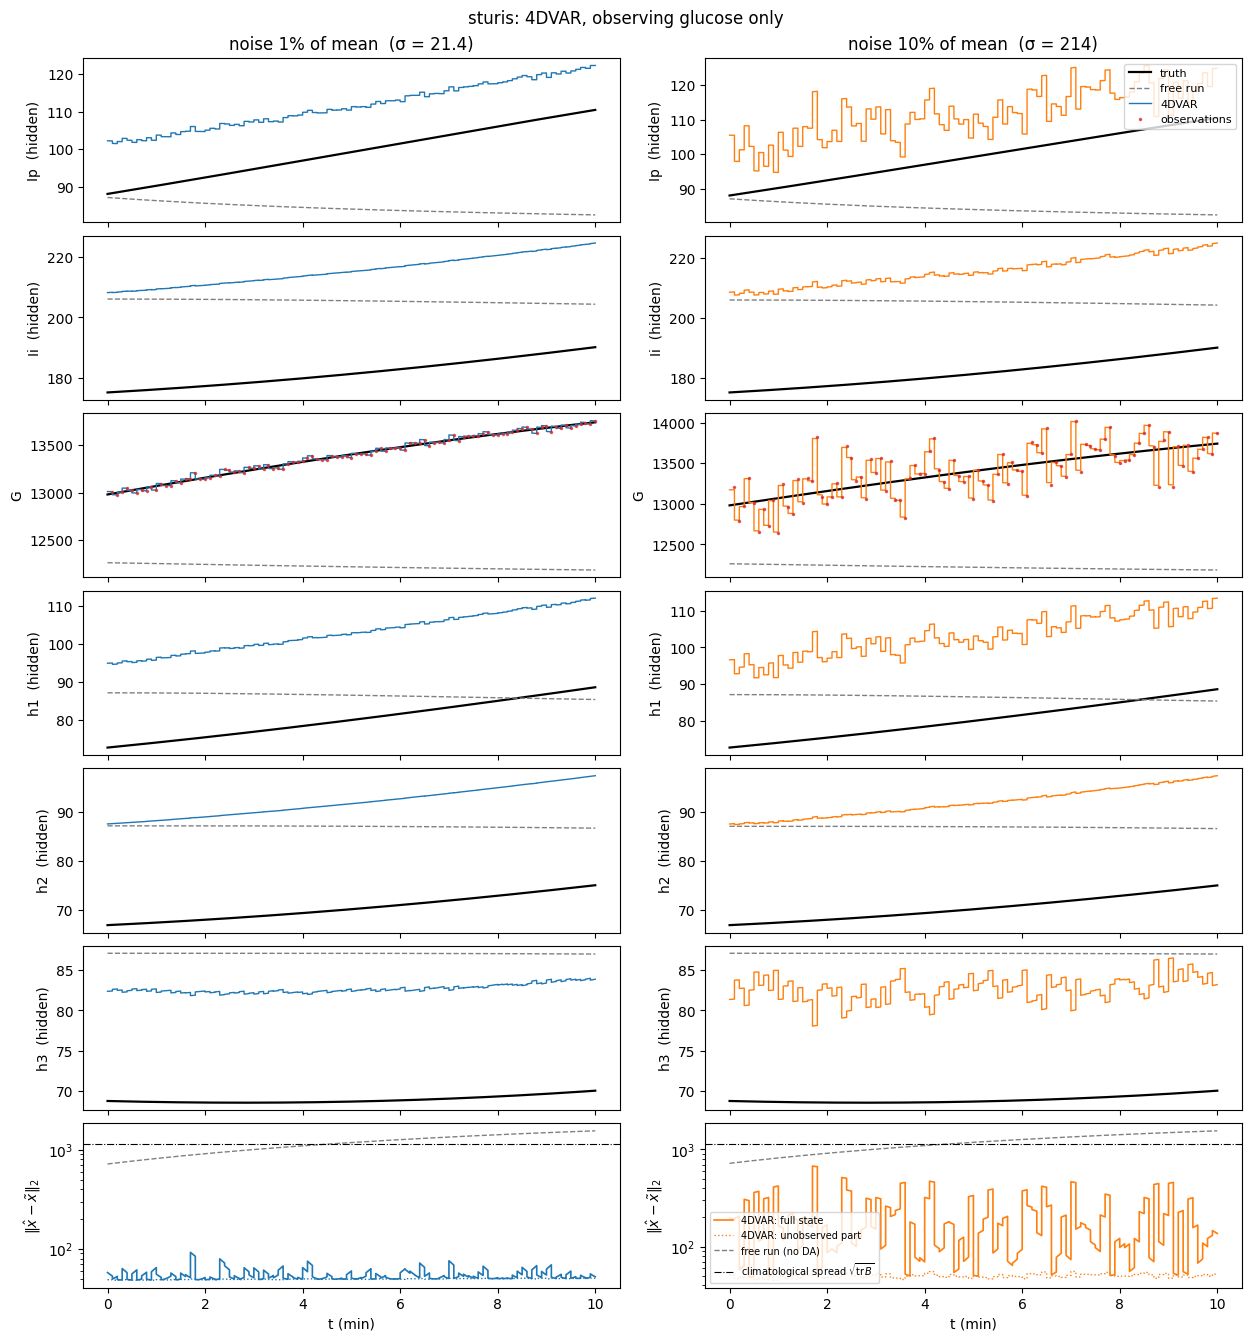

In [14]:
name = "sturis"
cr = [(c, r) for c, r in results_4d[name] if c["operator"] == "glucose only"]
plot_case_timeseries(models[name], [c for c, _ in cr], [r for _, r in cr], free_runs[name], method="4DVAR")
plt.show()

**Discussion:** 